# **Installations**

In [ ]:
%pip install datasets huggingface_hub pandas matplotlib scikit-learn

# **Loading Data**

In [4]:
import pandas as pd

splits = {'BTC': 'data/BTC-00000-of-00001.parquet', 'TSLA': 'data/TSLA-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/TheFinAI/CLEF_Task3_Trading/" + splits["BTC"])
df.shape

(236, 8)

# **Ploting Prices**


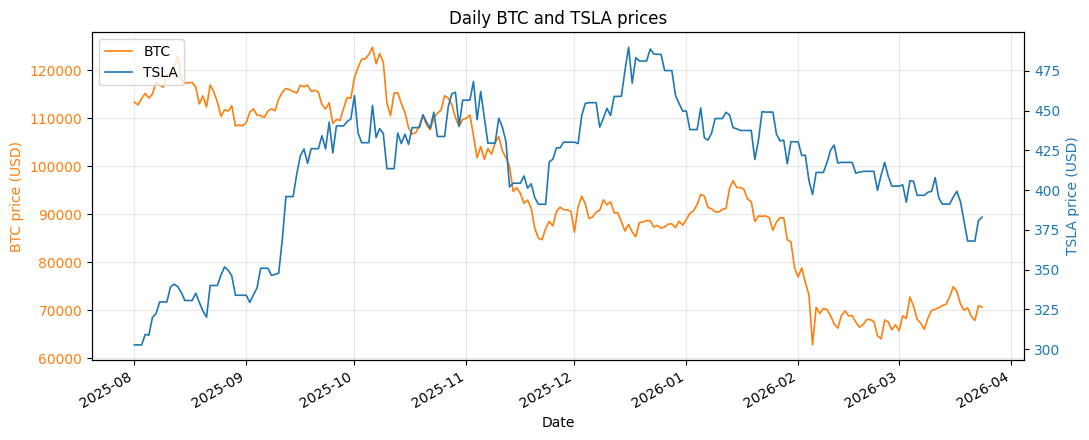

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

base = "hf://datasets/TheFinAI/CLEF_Task3_Trading/"
paths = {"BTC": "data/BTC-00000-of-00001.parquet", "TSLA": "data/TSLA-00000-of-00001.parquet"}


def load_daily(sym: str) -> pd.DataFrame:
    d = pd.read_parquet(base + paths[sym])
    d = d.copy()
    d["date"] = pd.to_datetime(d["date"])
    return d.sort_values("date")


btc_df = load_daily("BTC")
tsla_df = load_daily("TSLA")


fig, ax_btc = plt.subplots(figsize=(11, 4.5))
ax_btc.set_xlabel("Date")
ax_btc.set_ylabel("BTC price (USD)", color="tab:orange")
ax_btc.plot(btc_df["date"], btc_df["prices"], color="tab:orange", label="BTC", linewidth=1.2)
ax_btc.tick_params(axis="y", labelcolor="tab:orange")
ax_btc.grid(True, alpha=0.3)

ax_tsla = ax_btc.twinx()
ax_tsla.set_ylabel("TSLA price (USD)", color="tab:blue")
ax_tsla.plot(tsla_df["date"], tsla_df["prices"], color="tab:blue", label="TSLA", linewidth=1.2)
ax_tsla.tick_params(axis="y", labelcolor="tab:blue")

ax_btc.set_title("Daily BTC and TSLA prices")
lines = ax_btc.get_lines() + ax_tsla.get_lines()
ax_btc.legend(lines, [ln.get_label() for ln in lines], loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# **Dividing Data using Cross Validation with 5 folds**

In [10]:
from sklearn.model_selection import TimeSeriesSplit


def time_series_split_train_val_test(df: pd.DataFrame, n_splits: int = 5, date_col: str = "date"):
    """Return (train_df, val_df, test_df) using TimeSeriesSplit.

    We treat the last fold as `Test`, and the second-to-last fold as `Val`.
    """
    df = df.sort_values(date_col).reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    splits = list(tscv.split(df))

    train_idx, val_idx = splits[-2]
    _, test_idx = splits[-1]

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()
    test_df = df.iloc[test_idx].copy()
    return train_df, val_df, test_df


def print_split_ranges(df_part: pd.DataFrame, label: str, symbol: str):
    if df_part.empty:
        print(f"{symbol} {label}: empty")
        return

    start_date = df_part["date"].min().date()
    end_date = df_part["date"].max().date()
    start_idx = int(df_part.index.min())
    end_idx = int(df_part.index.max())

    print(f"{symbol} {label}: {start_date} .. {end_date} (idx {start_idx}..{end_idx}, n={len(df_part)})")


print("\nTimeSeriesSplit(n_splits=5) boundaries")

btc_train_df, btc_val_df, btc_test_df = time_series_split_train_val_test(btc_df, n_splits=5)
tsla_train_df, tsla_val_df, tsla_test_df = time_series_split_train_val_test(tsla_df, n_splits=5)

print_split_ranges(btc_train_df, "Train", "BTC")
print_split_ranges(btc_val_df, "Val", "BTC")
print_split_ranges(btc_test_df, "Test", "BTC")

print_split_ranges(tsla_train_df, "Train", "TSLA")
print_split_ranges(tsla_val_df, "Val", "TSLA")
print_split_ranges(tsla_test_df, "Test", "TSLA")


def print_folds(df: pd.DataFrame, symbol: str, n_splits: int = 5, date_col: str = "date"):
    df_sorted = df.sort_values(date_col).reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=n_splits)
    splits = list(tscv.split(df_sorted))

    print(f"\n{symbol} fold ranges (TimeSeriesSplit n_splits={n_splits}):")
    for i, (tr, te) in enumerate(splits):
        tr_start = df_sorted[date_col].iloc[tr[0]].date()
        tr_end = df_sorted[date_col].iloc[tr[-1]].date()
        te_start = df_sorted[date_col].iloc[te[0]].date()
        te_end = df_sorted[date_col].iloc[te[-1]].date()

        role = "Val" if i < n_splits - 1 else "Test"
        print(f"  Fold {i}: Train {tr_start} .... {tr_end}, {role} {te_start} .. {te_end}")


print_folds(btc_df, "BTC")
print_folds(tsla_df, "TSLA")



TimeSeriesSplit(n_splits=5) boundaries
BTC Train: 2025-08-01 .. 2026-01-05 (idx 0..157, n=158)
BTC Val: 2026-01-06 .. 2026-02-13 (idx 158..196, n=39)
BTC Test: 2026-02-14 .. 2026-03-24 (idx 197..235, n=39)
TSLA Train: 2025-08-01 .. 2026-01-05 (idx 0..157, n=158)
TSLA Val: 2026-01-06 .. 2026-02-13 (idx 158..196, n=39)
TSLA Test: 2026-02-14 .. 2026-03-24 (idx 197..235, n=39)

BTC fold ranges (TimeSeriesSplit n_splits=5):
  Fold 0: Train 2025-08-01 .... 2025-09-10, Val 2025-09-11 .. 2025-10-19
  Fold 1: Train 2025-08-01 .... 2025-10-19, Val 2025-10-20 .. 2025-11-27
  Fold 2: Train 2025-08-01 .... 2025-11-27, Val 2025-11-28 .. 2026-01-05
  Fold 3: Train 2025-08-01 .... 2026-01-05, Val 2026-01-06 .. 2026-02-13
  Fold 4: Train 2025-08-01 .... 2026-02-13, Test 2026-02-14 .. 2026-03-24

TSLA fold ranges (TimeSeriesSplit n_splits=5):
  Fold 0: Train 2025-08-01 .... 2025-09-10, Val 2025-09-11 .. 2025-10-19
  Fold 1: Train 2025-08-01 .... 2025-10-19, Val 2025-10-20 .. 2025-11-27
  Fold 2: Train 

**Information**

**BTC:**<br>
Train: 158 <br>
Val: 39<br>
Test: 39<br>

**TSLA:**<br>
Train: 158<br>
Val: 39<br>
Test: 39<br>


# **Prices Feature Extraction**